In [1]:
import perceval as pcvl
from perceval.components import BS, PS, PERM
from perceval.algorithm import Sampler, Analyzer
from perceval.rendering.circuit import DisplayConfig, SymbSkin
DisplayConfig.select_skin(SymbSkin) #Display settings for the circuits

import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm
import pandas as pd

This code reproduces the experimental results in our recent paper "Interaction-free measurement of multiple objects using a universal integrated photonic processor". We will remotely access Quandela's Ascella Quantum Processing Unit (QPU), a 12-mode, programmable universal photonic processor available through the [Quandela Cloud service](https://cloud.quandela.com/). We will interface with the device using the [Perceval framework](https://perceval.quandela.net/docs/v1.1/index.html) developped by Quandela.

Start by introducing a directory in the cell below where you want the data files to be saved. We will use these files to plot the data later. You will also need to create a user access token in the Quandela Cloud website in order to remotely access the QPU. Details on how to achieve this can be found in the ["Remote Computing" tutorial](https://perceval.quandela.net/docs/v1.1/notebooks/Remote_Computation_Tutorial.html) in Perceval documentation. 

In [65]:
#FILL IN THIS CELL

#Where the csv files with the data are saved:
directory = "     " #fill in

#User authentication token for cloud access (see "Remote Computing" tutorial in perceval documentation):
token = "        " #fill in
remote_config = pcvl.RemoteConfig()
remote_config.set_token(token)
remote_config.save()

# Efficiency

In [40]:
#Figure of merit for the protocols

def Efficiency(P_IFM,P_object):

    return P_IFM/(P_object + P_IFM)

# Elitzur-Vaidman protocol

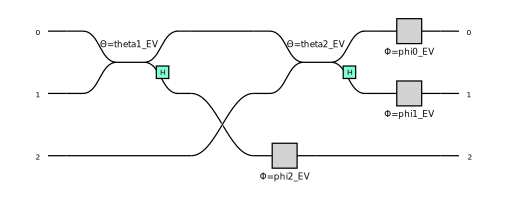

In [5]:
#Create perceval circuit with tunable parameters

EV = pcvl.Circuit(3)

theta_BS1_EV = pcvl.P("theta1_EV") #R=cos(theta/2)^2 reflectivity
theta_BS2_EV = pcvl.P("theta2_EV")

phi0_EV = pcvl.P("phi0_EV") #random phases added for error mitigation (see App. A.2 of paper for details)
phi1_EV = pcvl.P("phi1_EV")
phi2_EV = pcvl.P("phi2_EV")

EV // (0,BS.H(theta = theta_BS1_EV)) // (1,PERM([1,0])) // (0,BS.H(theta = theta_BS2_EV)) #BS.H^dag = BS.H
EV // (0,PS(phi = phi0_EV)) // (1,PS(phi = phi1_EV))// (2,PS(phi = phi2_EV))

pcvl.pdisplay(EV)

In [58]:
#Simulate with Analyzer to check expected results
theta=np.pi/2
R=np.cos(theta/2)**2
theta_BS1_EV.set_value(theta) #balanced beamsplitters
theta_BS2_EV.set_value(theta)

phi0_EV_random = np.random.random()*2*np.pi
phi1_EV_random = np.random.random()*2*np.pi
phi2_EV_random = np.random.random()*2*np.pi
phi0_EV.set_value(phi0_EV_random)
phi1_EV.set_value(phi1_EV_random)
phi2_EV.set_value(phi2_EV_random)

input_state_EV = pcvl.BasicState([1,0,0]) #single photons sent through top mode 

#Instantiate a processor, and pass it a backend and the circuit:
p = pcvl.Processor("SLOS", EV)

#Call the analyzer, which displays a table with the desired output states and corresponding probabilities
analyzer = Analyzer(p, [input_state], '*')  # '*' means all possible output states
pcvl.pdisplay(analyzer)

,"|1,0,0>","|0,0,1>","|0,1,0>"
"|1,0,0>",1/4,1/2,1/4


In [61]:
#Compute efficiency
a = analyzer.compute() #generate dictionary from analyzer outputs
probs = a['results'][0] #output probabilities

P_object = np.real(probs[1])
P_IFM = np.real(probs[2])
efficiency = Efficiency(P_IFM,P_object)
print("The efficiency of the EV protocol for R = {} is {}.".format(np.round(R,2),efficiency))

The efficiency of the EV protocol for R = 0.5 is 0.3333333333333334.


## Collect data from ascella

We can now retrieve data directly from the ascella QPU.

In [62]:
n = 12 #number of R values
Rs = np.linspace(0,1,n) #data points
epsilon = 1e-2 #to avoid numerical indetermination in efficiency for R=1
Rs[-1] = 1-epsilon
thetas = 2*np.arccos(np.sqrt(Rs)) #corresponding theta values

input_state_EV = pcvl.BasicState([1,0,0])

nsamples = 200000 #number of samples retrieved in a given call
M = 40 #number of random circuits for each R value

In [ ]:
for theta in thetas:
    
    theta_BS1_EV.set_value(theta) 
    theta_BS2_EV.set_value(theta)

    phi0_EVs = np.random.uniform(0,2*np.pi,M) #generate M random phases
    phi1_EVs = np.random.uniform(0,2*np.pi,M)
    phi2_EVs = np.random.uniform(0,2*np.pi,M)

    P_IFM_R = [] #to store retrived photon counts
    P_object_R = [] #to store retrived photon counts
    etas_R = [] #to store computed efficiencies
    
    for i in range(M):
        
        phi0_EV.set_value(phi0_EVs[i])
        phi1_EV.set_value(phi1_EVs[i])
        phi2_EV.set_value(phi2_EVs[i])
        
        #Create Remote Processor
        remote_qpu_EV = pcvl.RemoteProcessor("qpu:ascella")
        
        #Specify circuit, source and post-selection parameters
        remote_qpu_EV.set_circuit(EV)
        remote_qpu_EV.with_input(input_state_EV)
        remote_qpu_EV.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 
                                                      #(Keep only outcomes where at least one photon is detected)
        sampler_qpu_EV = Sampler(remote_qpu_EV, max_shots_per_call=nsamples)
        remote_job_qpu_EV = sampler_qpu_EV.sample_count.execute_async(nsamples)  # Create remote job
        
        #monitor job status
        previous_prog = 0
        with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
            tq.set_description(f'Get {nsamples} samples from {remote_qpu_EV.name}')
            while not remote_job_qpu_EV.is_complete:
                tq.update(remote_job_qpu_EV.status.progress/100-previous_prog)
                previous_prog = remote_job_qpu_EV.status.progress/100
                time.sleep(1)
            tq.update(1-previous_prog)
            tq.close()
        
        print(f"Job status = {remote_job_qpu_EV.status()}")
        
        #retrieve sampling results
        results_qpu_EV = remote_job_qpu_EV.get_results()
        
        P_IFM = results_qpu_EV['results'][pcvl.BasicState([0,1,0])]/nsamples #estimate probability from sample counts
        P_IFM_R.append(P_IFM)
        P_object = results_qpu_EV['results'][pcvl.BasicState([0,0,1])]/nsamples
        P_object_R.append(P_object)
        efficiency = Efficiency(P_IFM,P_object)
        etas_R.append(efficiency)
        
        print(results_qpu_EV['results'])

    #Store data in csv files
    data = {'R': np.cos(theta/2)**2, 'phi0': phi0_EVs, 'phi1': phi1_EVs, 'phi2': phi2_EVs, 'P_IFM': P_IFM_R, 'P_object': P_object_R, 'eta': etas_R,'M': M, 'nsamples': nsamples}
    dataframe = pd.DataFrame(data)
    dataframe.to_csv(directory + "/EV_R={},M={}.csv".format(np.round(np.cos(theta/2)**2,5),M), mode = "w", index = False, header = True)

## Read data from csv files and plot

<Figure size 1000x1000 with 0 Axes>

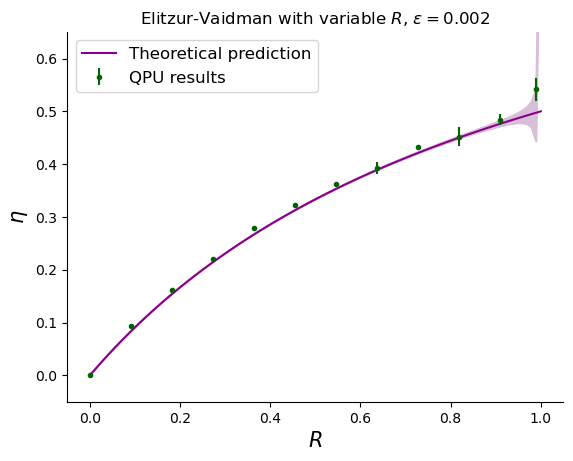

In [67]:
M=40
nsamples = 200000
R = np.linspace(0,1,100)

plt.figure(figsize = (10,10))
fig, ax = plt.subplots()
ax.spines[["top", "right"]].set_visible(False)

#Shaded area
epsilon = 0.002
eta_noisy_plus = (R*(1 - (1 + epsilon)*R)) / (R*(1-(1 + epsilon)*R) - R + 1)
ax.plot(R,eta_noisy_plus,color ='thistle')
eta_noisy_minus = (R*(1 - (1 - epsilon)*R)) / (R*(1-(1 - epsilon)*R) - R + 1)
ax.plot(R,eta_noisy_minus,color = 'thistle')    
ax.fill_between(R,eta_noisy_plus,eta_noisy_minus,color='thistle')

etas = []
etas_stds = []

for theta in thetas:
    df = pd.read_csv(directory + "/EV_R={},M={}.csv".format(np.round(np.cos(theta/2)**2,5),M), sep = ",")
    
    PIFMs = df['P_IFM'].to_numpy()
    PIFM_mean = np.mean(PIFMs)
    PIFM_std = np.std(PIFMs)/(np.sqrt(M))
                                     
    Pobjects = df['P_object'].to_numpy()
    Pobject_mean = np.mean(Pobjects)
    Pobject_std = np.std(Pobjects)/(np.sqrt(M))
    
    eta_mean = PIFM_mean/(PIFM_mean + Pobject_mean)
    etas.append(eta_mean)
    eta_std = np.sqrt((PIFM_mean**2 * Pobject_std**2 + Pobject_mean**2 * PIFM_std**2)/(PIFM_mean + Pobject_mean)**4)
    etas_stds.append(eta_std)

plt.plot(R,R/(R+1),label = "Theoretical prediction",color = "darkmagenta")
plt.errorbar(Rs, etas, etas_stds, fmt='.',color = "darkgreen", label = "QPU results")
plt.xlabel(r"$R$",fontsize=15)
plt.ylabel(r"$\eta$",fontsize=15)
plt.legend(fontsize=12)
plt.ylim(ymax=0.65)
plt.title(r"Elitzur-Vaidman with variable $R$, $\epsilon ={} $".format(epsilon))
plt.show()

# Multiple objects

## One object - Same as the EV protocol

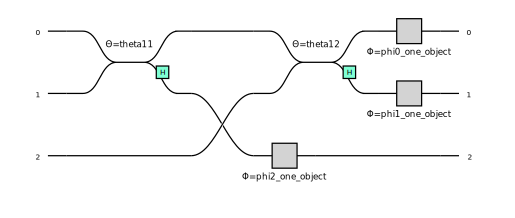

In [70]:
one_objects_circuit = pcvl.Circuit(3)
input_state_one_object = pcvl.BasicState([1,0,0])

phi0_one_object = pcvl.P("phi0_one_object") #random phases for error mitigation (see App.A2 of paper for details)
phi1_one_object = pcvl.P("phi1_one_object")
phi2_one_object = pcvl.P("phi2_one_object")

theta_BS11 = pcvl.P("theta11")
theta_BS12 = pcvl.P("theta12")

one_objects_circuit.add(0,BS.H(theta = theta_BS11)).add(1,PERM([1,0])).add(0,BS.H(theta = theta_BS12))
one_objects_circuit // (0,PS(phi = phi0_one_object)) // (1,PS(phi = phi1_one_object))// (2,PS(phi = phi2_one_object))

pcvl.pdisplay(one_objects_circuit)

In [ ]:
nsamples = 200000
M = 40 #number of circuits

P_IFMs=[]
P_objects=[]
etas=[]

theta_BS11.set_value(np.pi/2) #balanced beamsplitters
theta_BS12.set_value(np.pi/2)

phi0_one_objects = np.random.uniform(0,2*np.pi,M)
phi1_one_objects = np.random.uniform(0,2*np.pi,M)
phi2_one_objects = np.random.uniform(0,2*np.pi,M)

In [ ]:
for i in range(M):
    
    phi0_one_object.set_value(phi0_one_objects[i])
    phi1_one_object.set_value(phi1_one_objects[i])
    phi2_one_object.set_value(phi2_one_objects[i])
    
    #Create Remote Processor
    remote_qpu_one_object = pcvl.RemoteProcessor("qpu:ascella")
    
    #Specify circuit, source and post-selection parameters
    
    remote_qpu_one_object.set_circuit(one_objects_circuit)
    remote_qpu_one_object.with_input(input_state_one_object)
    remote_qpu_one_object.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 

    sampler_qpu_one_object = Sampler(remote_qpu_one_object, max_shots_per_call=nsamples)
    remote_job_qpu_one_object = sampler_qpu_one_object.sample_count.execute_async(nsamples)  # Create job
    
    #monitor job status
    previous_prog = 0
    with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
        tq.set_description(f'Get {nsamples} samples from {remote_qpu_one_object.name}')
        while not remote_job_qpu_one_object.is_complete:
            tq.update(remote_job_qpu_one_object.status.progress/100-previous_prog)
            previous_prog = remote_job_qpu_one_object.status.progress/100
            time.sleep(1)
        tq.update(1-previous_prog)
        tq.close()
    
    print(f"Job status = {remote_job_qpu_one_object.status()}")

    #retrieve sampling results
    results_qpu_one_object = remote_job_qpu_one_object.get_results()

    P_IFM = results_qpu_one_object['results'][pcvl.BasicState([0,1,0])]/nsamples #estimate probability from sample counts
    P_object = (results_qpu_one_object['results'][pcvl.BasicState([0,0,1])])/nsamples
    P_IFMs.append(P_IFM)
    P_objects.append(P_object)
    etas.append(Efficiency(P_IFM,P_object))

data = {'phi0': phi0_one_objects, 'phi1': phi1_one_objects, 'phi2': phi2_one_objects, 'P_IFM': P_IFMs, 'P_object': P_objects,'eta': etas, 'M': M, 'nsamples': nsamples}
dataframe = pd.DataFrame(data)
dataframe.to_csv(directory + "/one_objects,M={}.csv".format(M), mode = "w", index = False, header = True)

## Two objects

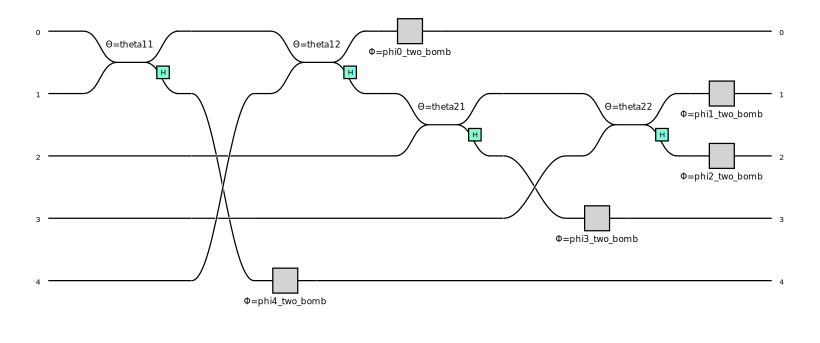

In [69]:
two_objects_circuit = pcvl.Circuit(5)
input_state_two_object = pcvl.BasicState([1,0,0,0,0])

phi0_two_object = pcvl.P("phi0_two_object") #random phases for error mitigation (see App.A2 of paper for details)
phi1_two_object = pcvl.P("phi1_two_object")
phi2_two_object = pcvl.P("phi2_two_object")
phi3_two_object = pcvl.P("phi3_two_object")
phi4_two_object = pcvl.P("phi4_two_object")

theta_BS11 = pcvl.P("theta11")
theta_BS12 = pcvl.P("theta12")
theta_BS21 = pcvl.P("theta21")
theta_BS22 = pcvl.P("theta22")

two_objects_circuit.add(0,BS.H(theta = theta_BS11)).add(1,PERM([3,1,2,0])).add(0,BS.H(theta = theta_BS12))

two_objects_circuit.add(1,BS.H(theta = theta_BS21)).add(2,PERM([1,0])).add(1,BS.H(theta = theta_BS22))

two_objects_circuit // (0,PS(phi = phi0_two_object)) // (1,PS(phi = phi1_two_object))// (2,PS(phi = phi2_two_object))\
// (3,PS(phi = phi3_two_object)) // (4,PS(phi = phi4_two_object))

pcvl.pdisplay(two_objects_circuit)

In [ ]:
nsamples = 200000
M = 40 #number of circuits

P_IFMs=[]
P_objects=[]
etas=[]

theta_BS11.set_value(np.pi/2) #balanced beamsplitters
theta_BS12.set_value(np.pi/2)
theta_BS21.set_value(np.pi/2) #balanced beamsplitters
theta_BS22.set_value(np.pi/2)

phi0_two_objects = np.random.uniform(0,2*np.pi,M)
phi1_two_objects = np.random.uniform(0,2*np.pi,M)
phi2_two_objects = np.random.uniform(0,2*np.pi,M)
phi3_two_objects = np.random.uniform(0,2*np.pi,M)
phi4_two_objects = np.random.uniform(0,2*np.pi,M)

In [ ]:
for i in range(M):
    
    phi0_two_object.set_value(phi0_two_objects[i])
    phi1_two_object.set_value(phi1_two_objects[i])
    phi2_two_object.set_value(phi2_two_objects[i])
    phi3_two_object.set_value(phi3_two_objects[i])
    phi4_two_object.set_value(phi4_two_objects[i])

    #Create Remote Processor
    remote_qpu_two_object = pcvl.RemoteProcessor("qpu:ascella")
    
    #Specify circuit, source and post-selection parameters
    
    remote_qpu_two_object.set_circuit(two_objects_circuit)
    remote_qpu_two_object.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 
                                                   #(I only want to keep outcomes where I detect at least one photon)
    remote_qpu_two_object.with_input(input_state_two_object)

    sampler_qpu_two_object = Sampler(remote_qpu_two_object, max_shots_per_call=nsamples)
    remote_job_qpu_two_object = sampler_qpu_two_object.sample_count.execute_async(nsamples)  # Create job
    
    #monitor job status
    previous_prog = 0
    with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
        tq.set_description(f'Get {nsamples} samples from {remote_qpu_two_object.name}')
        while not remote_job_qpu_two_object.is_complete:
            tq.update(remote_job_qpu_two_object.status.progress/100-previous_prog)
            previous_prog = remote_job_qpu_two_object.status.progress/100
            time.sleep(1)
        tq.update(1-previous_prog)
        tq.close()
    
    print(f"Job status = {remote_job_qpu_two_object.status()}")

    #retrieve sampling results
    results_qpu_two_object = remote_job_qpu_two_object.get_results()

    P_IFM = results_qpu_two_object['results'][pcvl.BasicState([0,0,1,0,0])]/nsamples #estimate probability from sample counts
    P_object = (results_qpu_two_object['results'][pcvl.BasicState([0,0,0,1,0])] + results_qpu_two_object['results'][pcvl.BasicState([0,0,0,0,1])])/nsamples
    P_IFMs.append(P_IFM)
    P_objects.append(P_object)
    etas.append(Efficiency(P_IFM,P_object))

data = {'phi0': phi0_two_objects, 'phi1': phi1_two_objects, 'phi2': phi2_two_objects, 'phi3': phi3_two_objects, 'phi4': phi4_two_objects, 'P_IFM': P_IFMs, 'P_object': P_objects,'eta': etas,'M': M, 'nsamples': nsamples}
dataframe = pd.DataFrame(data)
dataframe.to_csv(directory + "/two_objects,M={}.csv".format(M), mode = "w", index = False, header = True)

## Three objects

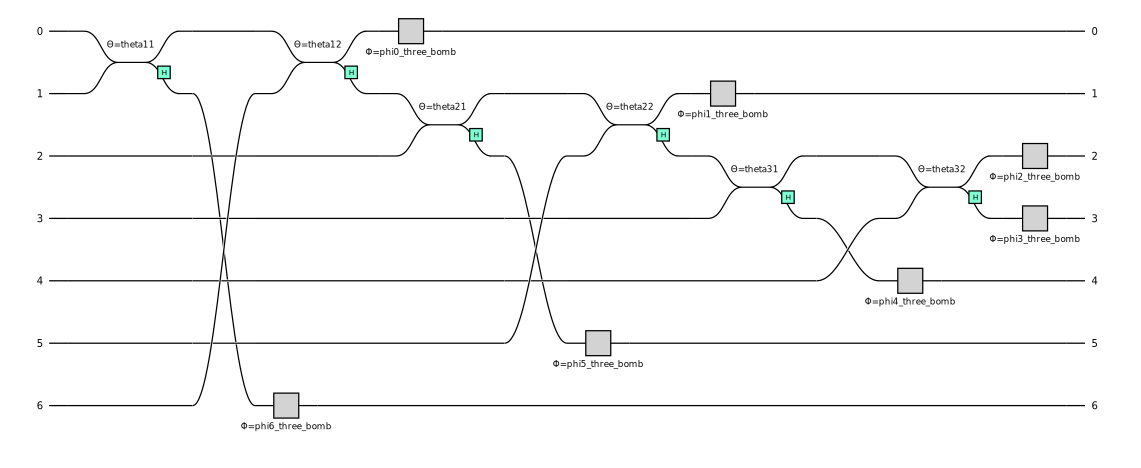

In [71]:
three_objects_circuit = pcvl.Circuit(7)
input_state_three_object = pcvl.BasicState([1,0,0,0,0,0,0])

phi0_three_object = pcvl.P("phi0_three_object") #random phases for error mitigation (see App.A2 of paper for details)
phi1_three_object = pcvl.P("phi1_three_object")
phi2_three_object = pcvl.P("phi2_three_object")
phi3_three_object = pcvl.P("phi3_three_object")
phi4_three_object = pcvl.P("phi4_three_object")
phi5_three_object = pcvl.P("phi5_three_object")
phi6_three_object = pcvl.P("phi6_three_object")

theta_BS11 = pcvl.P("theta11")
theta_BS12 = pcvl.P("theta12")
theta_BS21 = pcvl.P("theta21")
theta_BS22 = pcvl.P("theta22")
theta_BS31 = pcvl.P("theta31")
theta_BS32 = pcvl.P("theta32")

three_objects_circuit.add(0,BS.H(theta = theta_BS11)).add(1,PERM([5,1,2,3,4,0])).add(0,BS.H(theta = theta_BS12))

three_objects_circuit.add(1,BS.H(theta = theta_BS21)).add(2,PERM([3,1,2,0])).add(1,BS.H(theta = theta_BS22))

three_objects_circuit.add(2,BS.H(theta = theta_BS31)).add(3,PERM([1,0])).add(2,BS.H(theta = theta_BS32))

three_objects_circuit // (0,PS(phi = phi0_three_object)) // (1,PS(phi = phi1_three_object))// (2,PS(phi = phi2_three_object))\
// (3,PS(phi = phi3_three_object)) // (4,PS(phi = phi4_three_object)) // (5,PS(phi = phi5_three_object)) // (6,PS(phi = phi6_three_object))

pcvl.pdisplay(three_objects_circuit)

In [72]:
nsamples = 200000
M = 40 #number of circuits

P_IFMs=[]
P_objects=[]
etas=[]

theta_BS11.set_value(np.pi/2) #balanced beamsplitters
theta_BS12.set_value(np.pi/2)
theta_BS21.set_value(np.pi/2) #balanced beamsplitters
theta_BS22.set_value(np.pi/2)
theta_BS31.set_value(np.pi/2) #balanced beamsplitters
theta_BS32.set_value(np.pi/2)

phi0_three_objects = np.random.uniform(0,2*np.pi,M)
phi1_three_objects = np.random.uniform(0,2*np.pi,M)
phi2_three_objects = np.random.uniform(0,2*np.pi,M)
phi3_three_objects = np.random.uniform(0,2*np.pi,M)
phi4_three_objects = np.random.uniform(0,2*np.pi,M)
phi5_three_objects = np.random.uniform(0,2*np.pi,M)
phi6_three_objects = np.random.uniform(0,2*np.pi,M)

In [ ]:
for i in range(M):
    
    phi0_three_object.set_value(phi0_three_objects[i])
    phi1_three_object.set_value(phi1_three_objects[i])
    phi2_three_object.set_value(phi2_three_objects[i])
    phi3_three_object.set_value(phi3_three_objects[i])
    phi4_three_object.set_value(phi4_three_objects[i])
    phi5_three_object.set_value(phi5_three_objects[i])
    phi6_three_object.set_value(phi6_three_objects[i])

    #Create Remote Processor
    remote_qpu_three_object = pcvl.RemoteProcessor("qpu:ascella")
    
    #Specify circuit, source and post-selection parameters
    
    remote_qpu_three_object.set_circuit(three_objects_circuit)
    remote_qpu_three_object.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 
                                                   #(I only want to keep outcomes where I detect at least one photon)
    remote_qpu_three_object.with_input(input_state_three_object)

    sampler_qpu_three_object = Sampler(remote_qpu_three_object, max_shots_per_call=nsamples)
    remote_job_qpu_three_object = sampler_qpu_three_object.sample_count.execute_async(nsamples)  # Create job
    
    #monitor job status
    previous_prog = 0
    with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
        tq.set_description(f'Get {nsamples} samples from {remote_qpu_three_object.name}')
        while not remote_job_qpu_three_object.is_complete:
            tq.update(remote_job_qpu_three_object.status.progress/100-previous_prog)
            previous_prog = remote_job_qpu_three_object.status.progress/100
            time.sleep(1)
        tq.update(1-previous_prog)
        tq.close()
    
    print(f"Job status = {remote_job_qpu_three_object.status()}")

    #retrieve sampling results
    results_qpu_three_object = remote_job_qpu_three_object.get_results()

    P_IFM = results_qpu_three_object['results'][pcvl.BasicState([0,0,0,1,0,0,0])]/nsamples #estimate probability from sample counts
    P_object = (results_qpu_three_object['results'][pcvl.BasicState([0,0,0,0,1,0,0])] + results_qpu_three_object['results'][pcvl.BasicState([0,0,0,0,0,1,0])] \
            + results_qpu_three_object['results'][pcvl.BasicState([0,0,0,0,0,0,1])]) /nsamples
    P_IFMs.append(P_IFM)
    P_objects.append(P_object)
    etas.append(Efficiency(P_IFM,P_object))

data = {'phi0': phi0_three_objects, 'phi1': phi1_three_objects, 'phi2': phi2_three_objects, 'phi3': phi3_three_objects, 'phi4': phi4_three_objects,'phi5': phi5_three_objects, 'phi6': phi6_three_objects, 'P_IFM': P_IFMs, 'P_object': P_objects,'eta': etas,'M': M, 'nsamples': nsamples}
dataframe = pd.DataFrame(data)
dataframe.to_csv(directory + "/three_objects,M={}.csv".format(M), mode = "w", index = False, header = True)

## Four objects

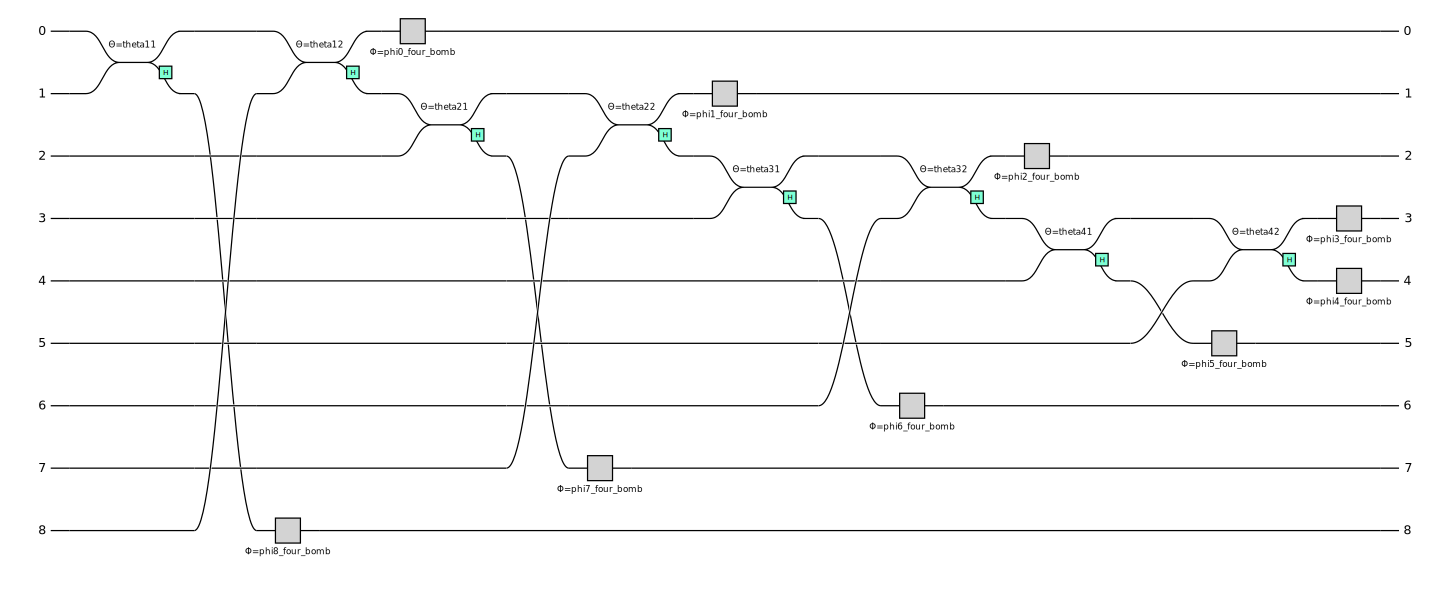

In [74]:
four_objects_circuit = pcvl.Circuit(9)
input_state_four_object = pcvl.BasicState([1,0,0,0,0,0,0,0,0])

phi0_four_object = pcvl.P("phi0_four_object") #random phases for error mitigation (see App.A2 of paper for details)
phi1_four_object = pcvl.P("phi1_four_object")
phi2_four_object = pcvl.P("phi2_four_object")
phi3_four_object = pcvl.P("phi3_four_object")
phi4_four_object = pcvl.P("phi4_four_object")
phi5_four_object = pcvl.P("phi5_four_object")
phi6_four_object = pcvl.P("phi6_four_object")
phi7_four_object = pcvl.P("phi7_four_object")
phi8_four_object = pcvl.P("phi8_four_object")

theta_BS11 = pcvl.P("theta11")
theta_BS12 = pcvl.P("theta12")
theta_BS21 = pcvl.P("theta21")
theta_BS22 = pcvl.P("theta22")
theta_BS31 = pcvl.P("theta31")
theta_BS32 = pcvl.P("theta32")
theta_BS41 = pcvl.P("theta41")
theta_BS42 = pcvl.P("theta42")

four_objects_circuit.add(0,BS.H(theta = theta_BS11)).add(1,PERM([7,1,2,3,4,5,6,0])).add(0,BS.H(theta = theta_BS12))

four_objects_circuit.add(1,BS.H(theta = theta_BS21)).add(2,PERM([5,1,2,3,4,0])).add(1,BS.H(theta = theta_BS22))

four_objects_circuit.add(2,BS.H(theta = theta_BS31)).add(3,PERM([3,1,2,0])).add(2,BS.H(theta = theta_BS32))

four_objects_circuit.add(3,BS.H(theta = theta_BS41)).add(4,PERM([1,0])).add(3,BS.H(theta = theta_BS42))

four_objects_circuit // (0,PS(phi = phi0_four_object)) // (1,PS(phi = phi1_four_object))// (2,PS(phi = phi2_four_object))\
// (3,PS(phi = phi3_four_object)) // (4,PS(phi = phi4_four_object)) // (5,PS(phi = phi5_four_object)) // (6,PS(phi = phi6_four_object))\
// (7,PS(phi = phi7_four_object)) // (8,PS(phi = phi8_four_object))

pcvl.pdisplay(four_objects_circuit)

In [75]:
nsamples = 200000
M = 40 #number of circuits

P_IFMs=[]
P_objects=[]
etas=[]

theta_BS11.set_value(np.pi/2) #balanced beamsplitters
theta_BS12.set_value(np.pi/2)
theta_BS21.set_value(np.pi/2) #balanced beamsplitters
theta_BS22.set_value(np.pi/2)
theta_BS31.set_value(np.pi/2) #balanced beamsplitters
theta_BS32.set_value(np.pi/2)
theta_BS41.set_value(np.pi/2) #balanced beamsplitters
theta_BS42.set_value(np.pi/2)

phi0_four_objects = np.random.uniform(0,2*np.pi,M)
phi1_four_objects = np.random.uniform(0,2*np.pi,M)
phi2_four_objects = np.random.uniform(0,2*np.pi,M)
phi3_four_objects = np.random.uniform(0,2*np.pi,M)
phi4_four_objects = np.random.uniform(0,2*np.pi,M)
phi5_four_objects = np.random.uniform(0,2*np.pi,M)
phi6_four_objects = np.random.uniform(0,2*np.pi,M)
phi7_four_objects = np.random.uniform(0,2*np.pi,M)
phi8_four_objects = np.random.uniform(0,2*np.pi,M)

In [ ]:
for i in range(M):
    
    phi0_four_object.set_value(phi0_four_objects[i])
    phi1_four_object.set_value(phi1_four_objects[i])
    phi2_four_object.set_value(phi2_four_objects[i])
    phi3_four_object.set_value(phi3_four_objects[i])
    phi4_four_object.set_value(phi4_four_objects[i])
    phi5_four_object.set_value(phi5_four_objects[i])
    phi6_four_object.set_value(phi6_four_objects[i])
    phi7_four_object.set_value(phi7_four_objects[i])
    phi8_four_object.set_value(phi8_four_objects[i])

    #Create Remote Processor
    remote_qpu_four_object = pcvl.RemoteProcessor("qpu:ascella")
    
    #Specify circuit, source and post-selection parameters
    
    remote_qpu_four_object.set_circuit(four_objects_circuit)
    remote_qpu_four_object.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 
                                                   #(I only want to keep outcomes where I detect at least one photon)
    remote_qpu_four_object.with_input(input_state_four_object)

    sampler_qpu_four_object = Sampler(remote_qpu_four_object, max_shots_per_call=nsamples)
    remote_job_qpu_four_object = sampler_qpu_four_object.sample_count.execute_async(nsamples)  # Create job
    
    #monitor job status
    previous_prog = 0
    with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
        tq.set_description(f'Get {nsamples} samples from {remote_qpu_four_object.name}')
        while not remote_job_qpu_four_object.is_complete:
            tq.update(remote_job_qpu_four_object.status.progress/100-previous_prog)
            previous_prog = remote_job_qpu_four_object.status.progress/100
            time.sleep(1)
        tq.update(1-previous_prog)
        tq.close()
    
    print(f"Job status = {remote_job_qpu_four_object.status()}")

    #retrieve sampling results
    results_qpu_four_object = remote_job_qpu_four_object.get_results()

    P_IFM = results_qpu_four_object['results'][pcvl.BasicState([0,0,0,0,1,0,0,0,0])]/nsamples #estimate probability from sample counts
    P_object = (results_qpu_four_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,0,1])] + results_qpu_four_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,1,0])]\
            + results_qpu_four_object['results'][pcvl.BasicState([0,0,0,0,0,0,1,0,0])] + results_qpu_four_object['results'][pcvl.BasicState([0,0,0,0,0,1,0,0,0])])/nsamples
    P_IFMs.append(P_IFM)
    P_objects.append(P_object)
    etas.append(Efficiency(P_IFM,P_object))

data = {'phi0': phi0_four_objects, 'phi1': phi1_four_objects, 'phi2': phi2_four_objects, 'phi3': phi3_four_objects, 'phi4': phi4_four_objects,'phi5': phi5_four_objects, \
        'phi6': phi6_four_objects,  'phi7': phi7_four_objects,  'phi8': phi8_four_objects, 'P_IFM': P_IFMs, 'P_object': P_objects,'eta': etas,'M': M, 'nsamples': nsamples}
dataframe = pd.DataFrame(data)
dataframe.to_csv(directory + "/four_objects,M={}.csv".format(M), mode = "w", index = False, header = True)

## Five objects

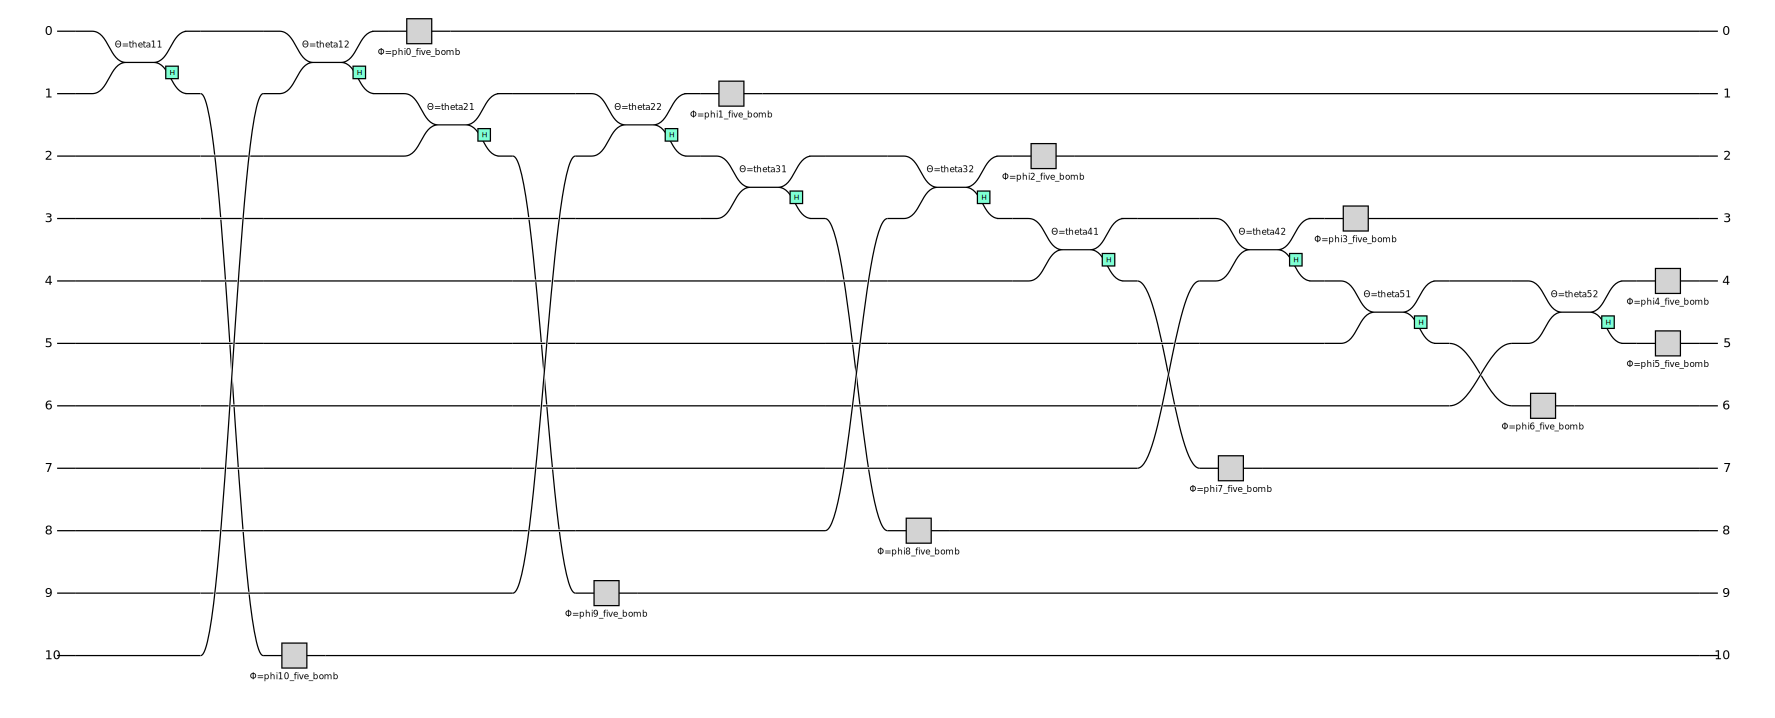

In [76]:
five_objects_circuit = pcvl.Circuit(11)
input_state_five_object = pcvl.BasicState([1,0,0,0,0,0,0,0,0,0,0])

phi0_five_object = pcvl.P("phi0_five_object") #random phases for error mitigation (see App.A2 of paper for details)
phi1_five_object = pcvl.P("phi1_five_object")
phi2_five_object = pcvl.P("phi2_five_object")
phi3_five_object = pcvl.P("phi3_five_object")
phi4_five_object = pcvl.P("phi4_five_object")
phi5_five_object = pcvl.P("phi5_five_object")
phi6_five_object = pcvl.P("phi6_five_object")
phi7_five_object = pcvl.P("phi7_five_object")
phi8_five_object = pcvl.P("phi8_five_object")
phi9_five_object = pcvl.P("phi9_five_object")
phi10_five_object = pcvl.P("phi10_five_object")

theta_BS11 = pcvl.P("theta11")
theta_BS12 = pcvl.P("theta12")
theta_BS21 = pcvl.P("theta21")
theta_BS22 = pcvl.P("theta22")
theta_BS31 = pcvl.P("theta31")
theta_BS32 = pcvl.P("theta32")
theta_BS41 = pcvl.P("theta41")
theta_BS42 = pcvl.P("theta42")
theta_BS51 = pcvl.P("theta51")
theta_BS52 = pcvl.P("theta52")

five_objects_circuit.add(0,BS.H(theta = theta_BS11)).add(1,PERM([9,1,2,3,4,5,6,7,8,0])).add(0,BS.H(theta = theta_BS12))

five_objects_circuit.add(1,BS.H(theta = theta_BS21)).add(2,PERM([7,1,2,3,4,5,6,0])).add(1,BS.H(theta = theta_BS22))

five_objects_circuit.add(2,BS.H(theta = theta_BS31)).add(3,PERM([5,1,2,3,4,0])).add(2,BS.H(theta = theta_BS32))

five_objects_circuit.add(3,BS.H(theta = theta_BS41)).add(4,PERM([3,1,2,0])).add(3,BS.H(theta = theta_BS42))

five_objects_circuit.add(4,BS.H(theta = theta_BS51)).add(5,PERM([1,0])).add(4,BS.H(theta = theta_BS52))

five_objects_circuit // (0,PS(phi = phi0_five_object)) // (1,PS(phi = phi1_five_object))// (2,PS(phi = phi2_five_object))\
// (3,PS(phi = phi3_five_object)) // (4,PS(phi = phi4_five_object)) // (5,PS(phi = phi5_five_object)) // (6,PS(phi = phi6_five_object))\
// (7,PS(phi = phi7_five_object)) // (8,PS(phi = phi8_five_object)) // (9,PS(phi = phi9_five_object)) // (10,PS(phi = phi10_five_object))

pcvl.pdisplay(five_objects_circuit)

In [77]:
nsamples = 200000
M = 40 #number of circuits

P_IFMs=[]
P_objects=[]
etas=[]

theta_BS11.set_value(np.pi/2) #balanced beamsplitters
theta_BS12.set_value(np.pi/2)
theta_BS21.set_value(np.pi/2) #balanced beamsplitters
theta_BS22.set_value(np.pi/2)
theta_BS31.set_value(np.pi/2) #balanced beamsplitters
theta_BS32.set_value(np.pi/2)
theta_BS41.set_value(np.pi/2) #balanced beamsplitters
theta_BS42.set_value(np.pi/2)
theta_BS51.set_value(np.pi/2) #balanced beamsplitters
theta_BS52.set_value(np.pi/2)

phi0_five_objects = np.random.uniform(0,2*np.pi,M)
phi1_five_objects = np.random.uniform(0,2*np.pi,M)
phi2_five_objects = np.random.uniform(0,2*np.pi,M)
phi3_five_objects = np.random.uniform(0,2*np.pi,M)
phi4_five_objects = np.random.uniform(0,2*np.pi,M)
phi5_five_objects = np.random.uniform(0,2*np.pi,M)
phi6_five_objects = np.random.uniform(0,2*np.pi,M)
phi7_five_objects = np.random.uniform(0,2*np.pi,M)
phi8_five_objects = np.random.uniform(0,2*np.pi,M)
phi9_five_objects = np.random.uniform(0,2*np.pi,M)
phi10_five_objects = np.random.uniform(0,2*np.pi,M)

In [ ]:
for i in range(M):
    
    phi0_five_object.set_value(phi0_five_objects[i])
    phi1_five_object.set_value(phi1_five_objects[i])
    phi2_five_object.set_value(phi2_five_objects[i])
    phi3_five_object.set_value(phi3_five_objects[i])
    phi4_five_object.set_value(phi4_five_objects[i])
    phi5_five_object.set_value(phi5_five_objects[i])
    phi6_five_object.set_value(phi6_five_objects[i])
    phi7_five_object.set_value(phi7_five_objects[i])
    phi8_five_object.set_value(phi8_five_objects[i])
    phi9_five_object.set_value(phi9_five_objects[i])
    phi10_five_object.set_value(phi10_five_objects[i])

    #Create Remote Processor
    remote_qpu_five_object = pcvl.RemoteProcessor("qpu:ascella")
    
    #Specify circuit, source and post-selection parameters
    
    remote_qpu_five_object.set_circuit(five_objects_circuit)
    remote_qpu_five_object.min_detected_photons_filter(1)  # Output state filtering on the basis of detected photons 
                                                           #(I only want to keep outcomes where I detect at least one photon)
    remote_qpu_five_object.with_input(input_state_five_object)

    sampler_qpu_five_object = Sampler(remote_qpu_five_object, max_shots_per_call=nsamples)
    remote_job_qpu_five_object = sampler_qpu_five_object.sample_count.execute_async(nsamples)  # Create job
    
    #monitor job status
    previous_prog = 0
    with tqdm(total=1, bar_format='{desc}{percentage:3.0f}%|{bar}|') as tq:
        tq.set_description(f'Get {nsamples} samples from {remote_qpu_five_object.name}')
        while not remote_job_qpu_five_object.is_complete:
            tq.update(remote_job_qpu_five_object.status.progress/100-previous_prog)
            previous_prog = remote_job_qpu_five_object.status.progress/100
            time.sleep(1)
        tq.update(1-previous_prog)
        tq.close()
    
    print(f"Job status = {remote_job_qpu_five_object.status()}")

    #retrieve sampling results
    results_qpu_five_object = remote_job_qpu_five_object.get_results()

    P_IFM = results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,1,0,0,0,0,0])]/nsamples #estimate probability from sample counts
    P_object = (results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,0,0,0,1])] + results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,0,0,1,0])]\
            + results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,0,1,0,0])] + results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,0,0,1,0,0,0])]\
            + results_qpu_five_object['results'][pcvl.BasicState([0,0,0,0,0,0,1,0,0,0,0])])/nsamples
    P_IFMs.append(P_IFM)
    P_objects.append(P_object)
    etas.append(Efficiency(P_IFM,P_object))

data = {'phi0': phi0_five_objects, 'phi1': phi1_five_objects, 'phi2': phi2_five_objects, 'phi3': phi3_five_objects, 'phi4': phi4_five_objects,'phi5': phi5_five_objects, \
        'phi6': phi6_five_objects,  'phi7': phi7_five_objects,  'phi8': phi8_five_objects, 'phi9': phi9_five_objects,  'phi10': phi10_five_objects, 'P_IFM': P_IFMs, 'P_object': P_objects,'eta': etas,'M': M, 'nsamples': nsamples}
dataframe = pd.DataFrame(data)
dataframe.to_csv(directory + "/five_objects,M={}.csv".format(M), mode = "w", index = False, header = True)

## Read data from csv files and plot

<Figure size 1000x1000 with 0 Axes>

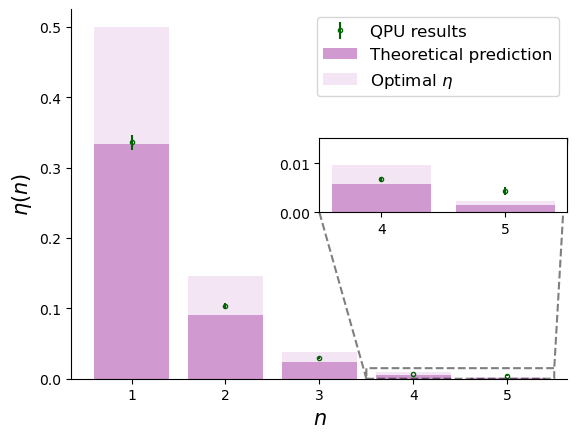

In [83]:
M=40 
etas = []
etas_stds = []
ns = np.array([1,2,3,4,5])
optimal_values = [0.5, 0.146447, 0.0380602, 0.00960736, 0.00240764]
theoretical_values = 1/(1 + 2/3*(4**ns-1))
numbers = ["one","two", "three", "four", "five"]

plt.figure(figsize = (10,10))
fig, ax = plt.subplots()
ax.spines[["top", "right"]].set_visible(False)

for number in numbers:
    
    df = pd.read_csv(directory + "/{}_objects,M={}.csv".format(number,M), sep = ",")
    
    P_IFMs = df['P_IFM'].to_numpy()
    P_IFM_mean = np.mean(P_IFMs)
    P_IFM_std = np.std(P_IFMs)/(np.sqrt(M))
                                     
    P_objects =df['P_object'].to_numpy()
    P_object_mean = np.mean(P_objects)
    P_object_std = np.std(P_objects)/(np.sqrt(M))
    
    eta_mean = P_IFM_mean/(P_IFM_mean + P_object_mean)
    etas.append(eta_mean)
    eta_std = np.sqrt((P_IFM_mean**2 * P_object_std**2 + P_object_mean**2 * P_IFM_std**2)/(P_IFM_mean + P_object_mean)**4)
    etas_stds.append(eta_std)
    
plt.errorbar(ns, etas, etas_stds, fmt='.',markerfacecolor = 'None',label = 'QPU results',color = 'darkgreen')
plt.bar(ns, theoretical_values,label = 'Theoretical prediction',width = 0.8, color = "darkmagenta", alpha = 0.4)
plt.bar(ns,optimal_values-theoretical_values, bottom = theoretical_values, label = r'$\text{Optimal } \eta$',width = 0.8, color = "darkmagenta", alpha = 0.1)

# inset
x1, x2, y1, y2 = 3.5, 5.5, 0, 0.015  # subregion of the original image
axins = ax.inset_axes(
    [0.5, 0.45, 0.5, 0.2],
    xlim=(x1, x2), ylim=(y1, y2))

ax.indicate_inset_zoom(axins, linestyle='--', linewidth = 1.5, edgecolor="black")
axins.set_xticks([4,5])
axins.errorbar(ns, etas, etas_stds, fmt='.',markerfacecolor = 'None',label = 'QPU results',color = 'darkgreen')
axins.bar(ns, theoretical_values,label = 'theory',width = 0.8, color = "darkmagenta", alpha = 0.4)
axins.bar(ns,optimal_values-theoretical_values, bottom = theoretical_values, label = 'optimal',width = 0.8, color = "darkmagenta", alpha = 0.1)

plt.xlabel(r"$n$", fontsize = 15)
plt.ylabel(r"$\eta (n)$", fontsize = 15)
plt.legend(fontsize = 12)
plt.show()